
## **Tackling CIFAR-10 With a DNN/CNN**





In this work, you need to modify the colab file to complete the CIFAR-10 task with a CNN. Please submit the completed colab file to Canvas (PRMLS Day 2 workshop submission).

Moreover, what kind(s) of setup/configuration does the colab training recipe use (not found in our lecturer slides) so that we can rapidly complete model training?

Please provide your answer below:

**[Answer here]**

---



## **1. Import libraries**



In [1]:
# Python ≥3.5 is asserted
import sys
assert sys.version_info >= (3, 5)

# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

# Scikit-Learn ≥0.20 is asserted
import sklearn
assert sklearn.__version__ >= "0.20"

# TensorFlow ≥2.0 is asserted
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

# Common imports
import matplotlib
import sklearn
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.callbacks import ModelCheckpoint,CSVLogger,LearningRateScheduler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import optimizers

print("Versions of key libraries")
print("---")
print("tensorflow: ", tf.__version__)
print("numpy:      ", np.__version__)
print("matplotlib: ", matplotlib.__version__)
print("sklearn:    ", sklearn.__version__)

No GPU was detected. CNNs can be very slow without a GPU.
Go to Runtime > Change runtime and select a GPU hardware accelerator.
Versions of key libraries
---
tensorflow:  2.19.0
numpy:       2.0.2
matplotlib:  3.10.0
sklearn:     1.6.1


## **2. Matplotlib setup**

In [2]:
plt.style.use('ggplot')
plt.rcParams['ytick.right']	= True
plt.rcParams['ytick.labelright']=	True
plt.rcParams['ytick.left']	= False
plt.rcParams['ytick.labelleft'] = False
plt.rcParams['font.family']	= 'Arial'

## **3. Data preparation**



In [3]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

# The following lines are incorrect for CNN input and will be removed
# X_train = X_train[..., np.newaxis]
# X_valid = X_valid[..., np.newaxis]
# X_test = X_test[..., np.newaxis]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
print("X_train_full.shape =", X_train_full.shape)
print("y_train_full.shape =", y_train_full.shape)
print("X_train.shape =", X_test.shape)
print("y_train.shape =", y_test.shape)
print("X_valid.shape =", X_valid.shape)
print("y_valid.shape =", y_test.shape)
print("X_test.shape =", X_test.shape)
print("y_test.shape =", y_test.shape)


X_train_full.shape = (50000, 32, 32, 3)
y_train_full.shape = (50000, 1)
X_train.shape = (10000, 32, 32, 3)
y_train.shape = (10000, 1)
X_valid.shape = (5000, 32, 32, 3)
y_valid.shape = (10000, 1)
X_test.shape = (10000, 32, 32, 3)
y_test.shape = (10000, 1)


## **4. Define model**

In [5]:
# DNN model here
imgrows=X_train_full.shape[1]
imgclms=X_train_full.shape[2]
channel=3
num_classes = 10

model = keras.Sequential()
#model.add(keras.layers.Dense(512, activation='relu', input_dim=3072))
#model.add(keras.layers.Dense(256, activation='relu'))
#model.add(keras.layers.Dense(256, activation='relu'))
#model.add(keras.layers.Dense(128, activation='relu'))
#model.add(keras.layers.Dense(10, activation='softmax'))

model.add(Conv2D(32, (3,3),
                     input_shape=(imgrows, imgclms, channel),
                     padding='same',
                     activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(48, (3,3),
                     padding='same',
                     activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3),
                     padding='same',
                     activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,450 (1.17 MB)

 Trainable params: 307,450 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Import to_categorical for one-hot encoding
# from tensorflow.keras.utils import to_categorical

# One-hot encode the labels
y_train_encoded = to_categorical(y_train, num_classes=10)
y_valid_encoded = to_categorical(y_valid, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

# Print the shape of the encoded labels
print(y_train_encoded.shape)
print(y_valid_encoded.shape)
print(y_test.shape)
print(y_test_encoded.shape)

(45000, 10)
(5000, 10)
(10000, 1)
(10000, 10)


In [7]:
# Set up optimizer
# from tensorflow.keras import optimizers
optmz = tf.keras.optimizers.RMSprop(learning_rate=0.0001)
model.compile(loss="categorical_crossentropy", optimizer=optmz, metrics=["accuracy"])


# create checkpoints to save model during training and save training data into csv
# from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
modelname = "cifar10_cnn"
filepath = modelname + ".keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_acc', verbose=0, save_best_only=True, mode='max')
csv_logger = CSVLogger(modelname+'.csv')
callbacks_list = [checkpoint, csv_logger]


## **5 & 6. Train and test a model**

In [ ]:
# train a model
# Note: Reshape the input data to flatten the images (for DNN)
# X_train_flattened = X_train.reshape(X_train.shape[0], -1)  # -1 infers the remaining dimension
# X_valid_flattened = X_valid.reshape(X_valid.shape[0], -1)
# X_test_flattened = X_test.reshape(X_test.shape[0], -1)
#X_train = X_train_flattened
#X_valid = X_valid_flattened
#X_test = X_test_flattened

# history = model.fit(X_train_flattened, y_train_encoded, epochs=4, validation_data=(X_valid_flattened, y_valid_encoded), callbacks=callbacks_list)
history = model.fit(X_train, y_train_encoded, epochs=4, validation_data=(X_valid, y_valid_encoded), callbacks=callbacks_list)

# The following evaluation and prediction calls are incorrect and will be removed/modified
# score = model.evaluate(X_test_flattened, y_test_encoded)
score = model.evaluate(X_test, y_test_encoded)

# X_new = X_test_flattened[:10] # pretend we have new images
X_new = X_test[:10] # pretend we have new images
y_pred = model.predict(X_new)

Epoch 1/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 102s 71ms/step - accuracy: 0.3403 - loss: 1.8539 - val_accuracy: 0.4926 - val_loss: 1.4420
Epoch 2/4
   1/1407 ━━━━━━━━━━━━━━━━━━━━ 1:48 77ms/step - accuracy: 0.5312 - loss: 1.3629

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):


1102/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step - accuracy: 0.5184 - loss: 1.3686

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the folder in your Google Drive
# Replace "your_folder_name" with the actual name of your folder
drive_folder_path = '/content/drive/My Drive/Colab Notebooks/PRMLS/Day 4/model'

# Create the folder if it doesn't exist
os.makedirs(drive_folder_path, exist_ok=True)

# Define the full path to save the model weights
model_save_path = os.path.join(drive_folder_path, modelname + ".weights.h5")

# Save the model weights to Google Drive
model.save_weights(model_save_path, overwrite=True)

print(f"Model weights saved to: {model_save_path}")

print (X_test.shape)
print (y_test_encoded.shape)
print (score)

print ("modelname =", modelname)
!pwd
!date
!ls -lh

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model weights saved to: /content/drive/My Drive/Colab Notebooks/PRMLS/Day 4/model/cifar10_cnn.weights.h5
(10000, 32, 32, 3)
(10000, 10)
[0.8917483687400818, 0.7103999853134155]
modelname = cifar10_cnn
/content
Wed Sep  3 12:48:11 PM UTC 2025
total 40M
-rw-r--r-- 1 root root 1.6K Sep  3 12:25 cifar10_cnn.csv
-rw-r--r-- 1 root root 2.4M Sep  3 12:25 cifar10_cnn.keras
-rw-r--r-- 1 root root 2.4M Sep  3 12:26 cifar10_cnn.weights.h5
-rw-r--r-- 1 root root  358 Sep  3 10:11 cifar10.csv
-rw-r--r-- 1 root root  123 Sep  3 10:22 cifar10_dnn.csv
-rw-r--r-- 1 root root  14M Sep  3 10:22 cifar10_dnn.keras
-rw-r--r-- 1 root root  14M Sep  3 10:11 cifar10.keras
-rw-r--r-- 1 root root 7.0M Sep  3 10:21 cifar10.weights.h5
drwx------ 5 root root 4.0K Sep  3 12:44 drive
drwxr-xr-x 1 root root 4.0K Aug 29 13:43 sample_data


In [ ]:
# Calculate accuracy and confusion matrix
# import sklearn.metrics as metrics
# X_new = X_test[:10] # pretend we have new images
# y_new = y_test_encoded[:10]
y_pred = model.predict(X_test) # Make predictions on the entire test set
#y_pred = model.predict(X_test_flattened)

predout = np.argmax(y_pred, axis=1)
testout = np.argmax(y_test_encoded, axis=1)
# for Cifar 10
labelname = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
# unique_classes = np.unique(predout) # No need to filter unique classes for the whole test set
# adjusted_labelname = [labelname[i] for i in unique_classes] # Select labels corresponding to predicted classes

testScores = metrics.accuracy_score(testout,predout)
confusion = metrics.confusion_matrix(testout,predout)

print("Best accuracy (on testing dataset): %.2f%%" % (testScores*100))
print(metrics.classification_report(testout,predout,target_names=labelname,digits=4)) # Use all label names for the full test set
print(confusion)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
Best accuracy (on testing dataset): 71.04%
              precision    recall  f1-score   support

    airplane     0.7969    0.6750    0.7309      1000
  automobile     0.8479    0.7970    0.8216      1000
        bird     0.7250    0.5010    0.5925      1000
         cat     0.4900    0.5640    0.5244      1000
        deer     0.6876    0.6800    0.6838      1000
         dog     0.6448    0.5990    0.6210      1000
        frog     0.7851    0.8000    0.7925      1000
       horse     0.8286    0.6960    0.7565      1000
        ship     0.7020    0.9070    0.7914      1000
       truck     0.6797    0.8850    0.7689      1000

    accuracy                         0.7104     10000
   macro avg     0.7188    0.7104    0.7084     10000
weighted avg     0.7188    0.7104    0.7084     10000

[[675  17  28  30  21   2   6   6 144  71]
 [  8 797   2   5   1   2   5   3  45 132]
 [ 75  10 501 104  92  54  73  25  39  27]
 [ 17  12  41 564  57 145  

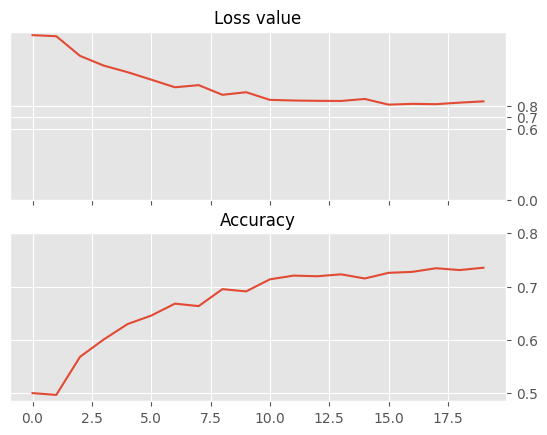

In [ ]:
# plot the result
# import pandas as pd
records = pd.read_csv(modelname+'.csv')
plt.figure()
plt.subplot(211)
plt.plot(records['val_loss'])
plt.yticks([0.00,0.60,0.70,0.80])
plt.title('Loss value',fontsize=12)
ax = plt.gca()
ax.set_xticklabels([])
plt.subplot(212)
#plt.plot(records['val_acc'])
plt.plot(records['val_accuracy'])
#plt.plot(records.get('val_accuracy', records.get('val_acc')))
plt.yticks([0.5,0.6,0.7,0.8])
plt.title('Accuracy',fontsize=12)
plt.show()

# CNN

#ResNet


# Transformer (Encoders only)

# CNN followed by Transformer Encoders